1 часть конспекта здесь: https://docs.google.com/document/d/1InODVkcCYe_qfZjV7X2fjJkvjTbR086HJfpeeVhFO88/edit?usp=sharing

<h1><center>T-распределение</center></h1> 

Если число наблюдений невелико (<30) и $\sigma$ неизвестно (почти всегда), **используется распределение Стьюдента (t-distribution)**, чтобы описать как ведут себя все выборочные средние.

## Почему используется Т-распределение?

При большом количестве наблюдений, больше 30, наше выборочное стандартное отклонение будет отражать соответсвующий параметр ГС, также наши выборочные средние будут **распределены нормальным образом**.

Однако при малом количестве наблюдений, меньше 30, мы чаще будет встречать случаи когда **выборочные средние будут сильно отклоняться от среднего ГС**. А также стандартное отклонение по выборке будет уже не таким хорошим.

Правильнее будет сказать, что мы используем t - распределение не потому что у нас маленькие выборки, а потому что мы не знаем стандартное отклонение в генеральной совокупности. Поэтому в дальнейшем мы всегда будем использовать t - распределение для проверки гипотез, если нам неизвестно стандартное отклонение в генеральной совокупности, необходимое для расчета стандартной ошибки, даже если объем выборки больше 30.

### Пример:

Представьте что в ГС среднее равняется 10, а мы взяли всего 5 элементов. Ничего удивительного в том, что мы можем получить среднее которое равняется 20 или 3



## Чем оно отличается от нормального распределения?

Основное отличие распределения Стьюдента в том, что у распределения Стьюдента более высокие хвосты распределения (это означает, что в диапозоне превыщающим +-2 $\sigma$ будет лежать больше наблюдений чем в нормальном распределении)

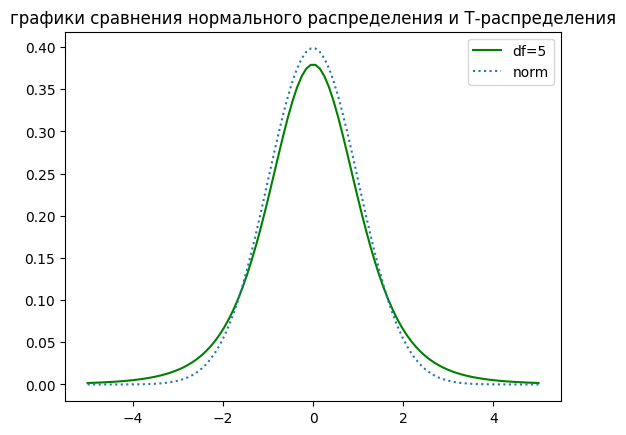

In [15]:
from scipy.stats import t, norm
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y1 = t.pdf(x, df=5)
y4 = norm.pdf(x)

plt.title('графики сравнения нормального распределения и Т-распределения')
plt.plot(x, y1, 'g')
plt.plot(x, y4, ':')
plt.legend(('df=5','norm'))
plt.show()

## Важный параметр Т-распределения

Число степеней свободы `df`, оно зависит от количество элементов в выборке **`df=n-1`** и определяет форму распределения. С увеличением числа `df` распределение стремится к нормальному.


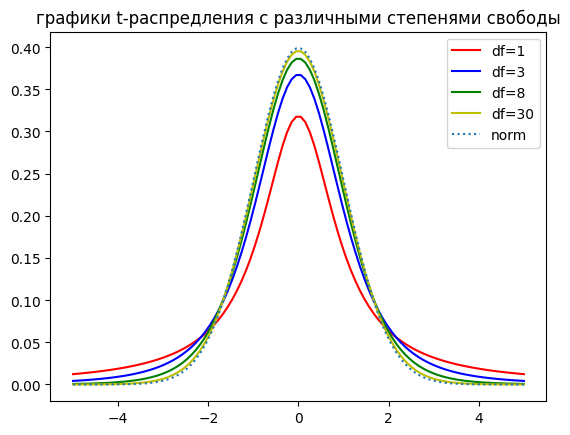

In [18]:
from scipy.stats import t, norm
import numpy as np
import matplotlib.pyplot as plt
''' График Т-распределения с различными степенями свободы'''

x = np.linspace(-5, 5, 100)
y1 = t.pdf(x, df=1)
y2 = t.pdf(x, df=3)
y3 = t.pdf(x, df=8)
y4 = t.pdf(x, df=30)
y5 = norm.pdf(x)

plt.title('графики t-распредления с различными степенями свободы')
plt.plot(x, y1, 'r')
plt.plot(x, y2, 'b')
plt.plot(x, y3, 'g')
plt.plot(x, y4, 'y')
plt.plot(x, y5, ':')
plt.legend(('df=1','df=3','df=8','df=30','norm'))
plt.show()

### Подробно про нормальное и t-распредление

В видео лекциях говорилось, что мы используем t-распределение в ситуации небольшого объема выборки. Необходимо более подробно пояснить, зачем это нужно.

Вернемся к предельной центральной теореме, мы уже узнали, что если некий признак в генеральной совокупности распределен **нормально** со средним $\mu$ и стандартным отклонением $\sigma$, и мы будем многократно извлекать выборки одинакового размера n, и для каждой выборки рассчитывать, как далеко выборочное среднее $\bar{X}$ ˉ
 отклонилось от среднего в генеральной совокупности в единицах стандартной ошибки среднего:
 

$$\large z = \frac{\bar{X} - \mu}{\frac{\sigma}{\sqrt{n}}}$$

то эта величина z будет иметь стандартное нормальное распределение со средним равным нулю и стандартным отклонением равным единице.

Обратите внимание, что для расчета стандартной ошибки мы используем именно стандартное отклонение в генеральной совокупности - $\sigma$. Ранее мы уже обсуждали, что на практике $\sigma$ нам практически никогда не известна, и для расчета стандартной ошибки мы используем выборочное стандартное отклонение.

Так вот, строго говоря в таком случае распределение отклонения выборочного среднего и среднего в генеральной совокупности, деленного на стандартную ошибку, теперь будет описываться именно при помощи t - распределения.

$$\large t = \frac{\bar{X} - \mu}{\frac{sd}{\sqrt{n}}}$$


таким образом, в случае неизвестной $\sigma$ мы **всегда будем иметь дело с t-распределением**. На этом этапе вы должны с негодованием спросить меня, почему же мы применяли z-критерий в первом модуле курса, для проверки гипотез, используя выборочное стандартное отклонение?

Мы уже знаем, что при довольно большом объеме выборки (обычно в учебниках приводится правило, n > 30) t-распределение совсем близко подбирается к нормальному распределению:

Поэтому иногда, для простоты расчетов говорится, что если n > 30, то мы будем использовать свойства нормального распределения для наших целей. Строго говоря, это конечно неправильный подход, который часто критикуют. В до компьютерную эпоху этому было некоторое объяснение, чтобы не рассчитывать для каждого n больше 30 соответствующее критическое значение t - распределения, статистики как бы округляли результат и использовали нормальное распределение для этих целей. Сегодня, конечно, с этим больше никаких проблем нет, и все статистические программы, разумеется, без труда рассчитают все необходимые показатели для t - распределения с любым числом степеней свободы. Действительно при выборках очень большого объема t - распределение практически не будет отличаться от нормального, однако, хоть и очень малые но различия все равно будут.

Поэтому, правильнее будет сказать, что мы используем t - распределение не потому что у нас маленькие выборки, а потому что мы не знаем стандартное отклонение в генеральной совокупности. Поэтому в дальнейшем мы всегда будем использовать t - распределение для проверки гипотез, если нам неизвестно стандартное отклонение в генеральной совокупности, необходимое для расчета стандартной ошибки, даже если объем выборки больше 30.


## Решение контеста

In [25]:
from scipy import stats

t = -2 # рассчитанное t-значение
n = 15 # количество наблюдений
df = n - 1 # количество степеней свободы

p = 2 * stats.t.sf(abs(t), df)

print(f'p = {p:.3f}')

p = 0.065


# Сравнение двух средних; t-критерий Стьюдента

Критерий, который позволяет сравнивать 2 выборки вместе, иными словами 2 выборочных средних, называется **парный Т-тест** или **критерий Стьюдента**

## Пример расчета t-критерия:
![Расчет критеря Стьюдента](images/1.png)

Правильнее было бы сформулировать нулевую гипотезу так:

- нулевая гипотеза - лекарство не работает, выборки принадлежат одной ГС
- альтернативная гипотеза - лекарство работает, выборки принадлежат разным ГС

## Пример №2:
![Расчет критеря Стьюдента](images/2.png)

## Как строить графики?

In [6]:
import pandas as pd
from scipy.stats import t
import matplotlib.pyplot as plt
import numpy as np

array1 = np.array([84.7, 105.0, 98.9, 97.9, 108.7, 81.3, 99.4, 89.4, 93.0,
                   119.3, 99.2, 99.4, 97.1, 112.4, 99.8, 94.7, 114.0, 95.1, 115.5, 111.5])
array2 = np.array([57.2, 68.6, 104.4, 95.1, 89.9, 70.8, 83.5, 60.1, 75.7,
                   102.0, 69.0, 79.6, 68.9, 98.6, 76.0, 74.8, 56.0, 55.6, 69.4, 59.5])

# считаем количество элементов, среднее, стандартное отклонение и стандартную ошибку
df = pd.DataFrame({'Выборка1':array1, 'Выборка2':array2}).agg(['mean','std','count','sem']).transpose()
df.columns = ['Mx','SD','N','SE']

# рассчитываем 95% интервал отклонения среднего
p = 0.95
K = t.ppf((1 + p)/2, df['Mx']-1)
df['interval'] = K * df['SE']

df

,Mx,SD,N,SE,interval
Выборка1,100.815,10.246503,20.0,2.291188,4.545754
Выборка2,75.735,15.458102,20.0,3.456537,6.886174


/tmp/ipykernel_5530/121899217.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot1 = ax1.boxplot([array1, array2],
/tmp/ipykernel_5530/121899217.py:11: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  bplot2 = ax2.errorbar(x=df.index, y=df['Mx'], yerr=df['interval'],\


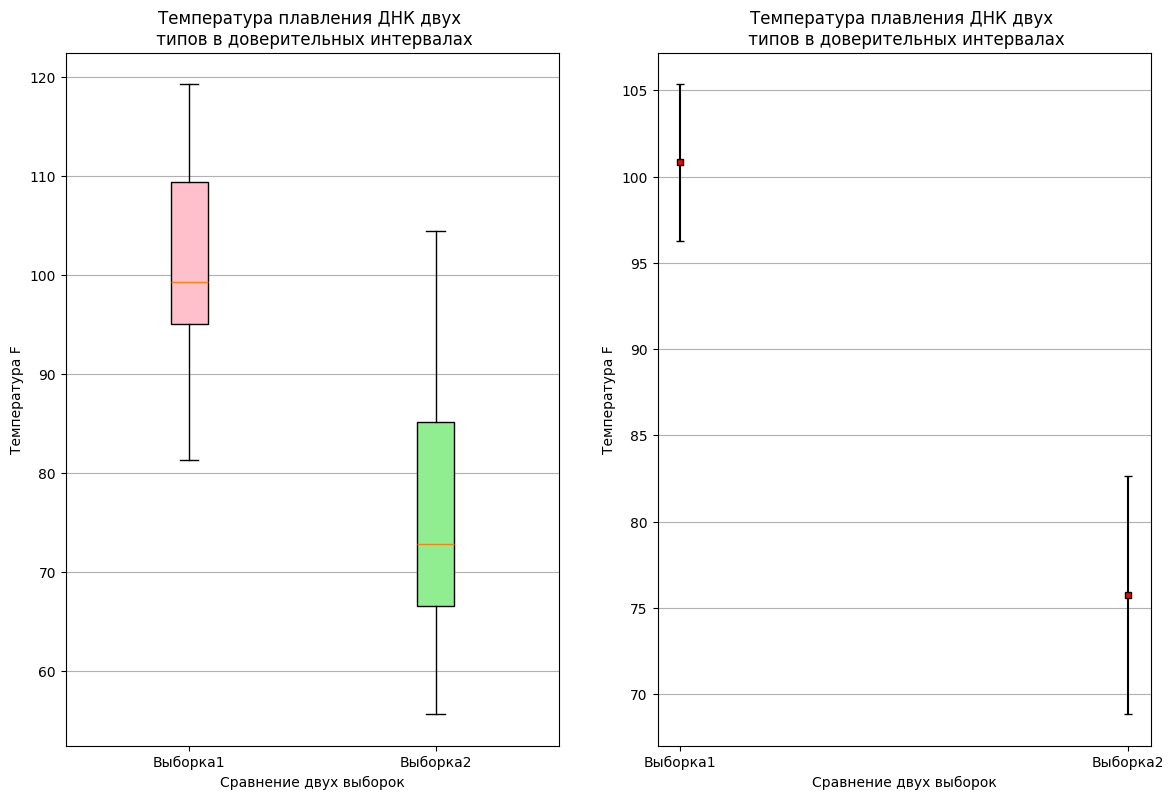

In [9]:


#строим графики, boxplot из изначальных данных array1, array2,  доверительные интервалы из датафрейма df
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 9))

# график boxplot
bplot1 = ax1.boxplot([array1, array2],
                     vert=True,  # создаем вертикальные боксы
                     patch_artist=True, # для красоты заполним цветом боксы квантилей
                     labels=['Выборка1', 'Выборка2']) # используется для задания значений выборок в случае с boxplot

# график доверительных интервалов
bplot2 = ax2.errorbar(x=df.index, y=df['Mx'], yerr=df['interval'],\
                      color="black", capsize=3, marker="s", markersize=4, mfc="red", mec="black", fmt ='o')

# раскрасим boxplot  
colors = ['pink', 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
    
# добавим общие для каждого из графиков данные
for ax in [ax1, ax2]:
    ax.yaxis.grid(True)
    ax.set_title('Температура плавления ДНК двух \n типов в доверительных интервалах')
    ax.set_xlabel('Сравнение двух выборок')
    ax.set_ylabel('Температура F')
    
plt.show()

График с доверительными интервалами очень хорошая вещь. Он дает:

- Исчерпывающее представление данных (Чем мы занимались и кого мы сравнивали)
- А также узнать о значимости различий (Если выборочное среднее второй выборки не входит в доверительный интервал первой выборки (и наоборот), то такие различия будут достигать уровня статистической значимости (p<0,05)

### **ВАЖНЫЕ условия при использовании критерия t-Стьюдента:**

- Гомогенность дисперсии (Желательно чтобы дисперсии наших групп были примерно равны). *Для проверки используют критерий Левена или критерий Фишера*
- Если объем выборки меньше 30, **тогда ВАЖНО чтобы наши 2 выборки были нормально распределены**. ( Скажем так, если у самого признака в выборках нормальное распределение, то для t - test все очень хорошо, а вот если нет ... то возможны всяческие нежелательные спецэффекты. Но при этом на практике, можно встретиться с применением t - test даже на ненормальных данных, и это нормально!))


## Работа над ошибками:

1. ![Задание1](images/3.png)

- ( n ) Количество наблюдений: Больше наблюдений, меньше p-value, увеличивает статистическую значимость.
- ( x̅ ) Среднее значение: Большее различие, меньше p-value, увеличивает статистическую значимость.
- ( se ) Ошибка среднего: Большая ошибка, больше p-value, снижает статистическую значимость.
- ( t ) T-критерий: Больше t-критерий, меньше p-value, увеличивает статистическую значимость

* чем меньше p-уровень значимости, тем более статистически значимыми считаются результаты ( p < α ), и тем больше оснований считать, что различия не случайны.

2. ![изображение.png](images/4.png)

- Поскольку наше число не отрицательное => среднее первого типа больше, а интервал говорит на сколько больше

**Ответ**: Число рибосом у первого типа бактерий в среднем на 100-300 рибосом превышает число рибосом у второго типа.

# Проверка распределения на нормальность, QQ-Plot

Самый простой способ построить **гистограмму частот и наложить кривую идеального нормального распределения**. Тогда по оси y будет не частота, а уже плотность распределения.

Выборка всегда будет немного отличаться от нормального распределения (это нормально) (если выборка имеет нормальное распределение)

Второй способ построить график QQ-plot (как я помню, он не очень понятный, ведь тяжело сказать на сколько должна отклониться линия, чтобы распределение считалось не нормальным)

## QQ-plot
Он показывает насколько наши выборочные значения хорошо соответсвуют предсказанным значениям, если бы наши значения были бы идеально нормальными.

- Пока наши все точки лежат на прямой -- это значит что наши реальные значения очень хорошо согласуются с нормальным распределением

![изображение.png](images/5_1.png)

- Как только наши точки начинают заползать над прямую -- это значит, что наши реальные значения **СЛИШКОМ ВЫСОКИЕ** в сравнении с нормальным распределением

![изображение.png](images/5_2.png)

- Как только наши точки начинают заползать под прямую -- это значит, что наши реальные значения **НИЗКИЕ** в сравнении с нормальным распределением

![изображение.png](images/5_3.png)


### Пример

Пример показывает как поведет себя прямая в случае не нормального распределения:

![изображение.png](images/5_4.png)

### Преимущество графика QQ-plot

- Когда у нас очень мало наблюдений в выборке его намного удобнее использовать (для этого случая у нас не хватает данных чтобы построить хорошую гистограмму частот)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


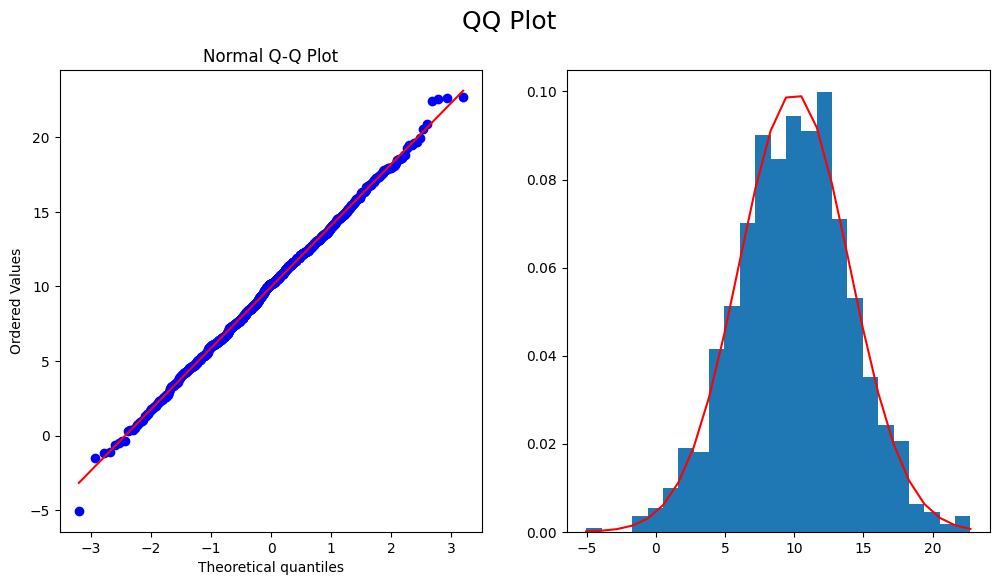

In [1]:
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 6]

mu, sigma = 10, 4
n = 1000 # с ростом числа точек в распределении qq-plot стремится к прямой
sequence = np.random.normal(mu, sigma, n)


fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('QQ Plot', fontsize=18)

# Q-Q Plot graph
stats.probplot(sequence, dist="norm", plot=ax1)
ax1.set_title("Normal Q-Q Plot")

# normal distribution histogram + distribution
count, bins, _ = ax2.hist(sequence, 25, density=True)
p_x = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) )
ax2.plot(bins, p_x, color='r')
 

plt.show()

## Статистические тесты (В обоих случаях нулевая гипотеза говорит о том, что ваша выборка извлечена из ГС, где распределение признака соответсвует нормальному)
### Тест Колмогорова-Смирнова

- Этот тест позволяет проверять вообще на разные распределения:
  - stats.kstest(data, 'uniform')     # равномерное
  - stats.kstest(data, 'expon')       # экспоненциальное
  - stats.kstest(data, 'gamma', args=(a,))  # гамма
  - stats.kstest(data, 'lognorm', args=(s,)) # логнормальное

In [6]:
import numpy as np
from scipy import stats

data = np.random.normal(0, 1, 100) 
stat, p_value = stats.kstest(data, 'norm')
p_value

0.5182384557547284

### Тест Шапиро-Вилка

In [7]:
from scipy import stats
import numpy as np

data = np.random.normal(0, 1, 100)
stat, p_value = stats.shapiro(data)
p_value

0.23315991900838928

### Как влияют выбросы на t-критерий?

Выбросы очень сильно влияют на критерий, ведь мы берем средние значения, а на средние значения сильно влияют выбросы.

![изображение.png](images/6.png)

### Что делать если наши признаки очень сильно отличаются от нормального? (и мы опасаемся использовать критерий t-Стьюдента)

В таких ситуациях используется не параметрический аналог - **Mann-Whitney U-test**

- Он переводит все наши данные в ранговую шкалу и считает какой средний ранг оказался у нас в каждой группе (Такой критерий гораздо менее чувствительный к экстримальным отклонениям от нормальности и к наличию выбросов)

# Однофакторный дисперсионный анализ

Очень часто в экспериментах и исследованиях возникает необходимость сравнить несколько групп между собой. В таком случае мы можем применять однофакторный дисперсионный анализ.  Та переменная, которая будет разделять наших испытуемых или наблюдения на группы (номинативная переменная с нескольким градациями) называется **независимой переменной**. А та количественная переменная, по степени выраженности которой мы сравниваем группы, называется **зависимая переменная**. 

Пример 1. У нас есть 3 типа лечения, мы хотим понять, есть ли между ними разница. Здесь независимая переменная - тип лечения(тип1, тип2, тип3). Зависимая переменная - некая величина, у каждого испытуемого, которая покажет вам насколько успешно было лечение(продолжительность  симптомов, средняя температура в течении недели после лечения, уровень вещества в крови и т.д.)

Пример 2. Хотим выяснить как различные удобрения влияют на рост помидоров, опять же у нас есть 3 удобрения. Независимая переменная - удобрения. Зависимая переменная - вес полученных томатов(или высота растения через Х дней). 

В общем, мы смотрим как что-то НЕЗАВИСИМОЕ, влияет на что-то другое, поэтому что-то другое(на которое мы влияем) называют ЗАВИСИМОЙ переменной. Интересующий нас показатель ЗАВИСИТ от чего-то, мы пытаемся выяснить природу этой зависимости.


## Схема использования:
1. **Сформулируем наши гипотезы:**

$$H_0: M_1 = M_2 = M_3$$
$$H_1: \exists i,j: M_i \ne M_j$$
- **Нулевая гипотеза** - все средние равные между собой
- **Альтернативная гипотеза** - хотя бы пара средних различаются между собой

2. **Для начала нам нужно вычислить среднее всех значений (То есть взять все наблюдения по всем группа и вычислить среднее)**
![изображение.png](images/7.png)

3. **Теперь нам нужно посчитать общую сумму квадратов (SST)**

- SST - это показатель, который характеризует изменчивость всех наших данных (без учета разделения по группам). (Он расчитывается как дисперсия)
- $$ SS_{total} = \sum_{j=1}^{p}{\sum_{i=1}^{n_j}{(x_{ij} - \bar{x})^2}} = SS_{between} + SS_{within} $$
- Число степеней свободы: $$df=N-1$$

![изображение.png](images/8.png)

4. **Теперь нам нужно посчитать Сумму квадратов между групп (SSB) и Сумму квадратов внутри групповая (SSW)**

- $ SS_{between} = \sum_{j=1}^{p}{n_j{(\bar{x}_j - \bar{x})^2}}, df=N-m $, где m - количество групп
- $ SS_{within} = \sum_{j=1}^{p}{\sum_{i=1}^{n_j}{(x_{ij} - \bar{x}_j)^2}}, df=m-1 $, где m - количество групп

5. **Интерпритация результатов**

- Если **большая часть нашей общей изменчивости** обеспечивается **благодаря SSB** (Сумме квадратов между групп) - это означает, что **наши группы значительно различаются между собой**
- Если **большая часть** нашей общей изменчивости обеспечивается **благодаря SSW** (Сумме квадратов внутри групповая) - это означает, что **наши группы не различаются между собой**

6. **Основной статистический показатель (F-value)**

- $$F = \frac{SS_{\text{between}} / (N - m)}{SS_{\text{within}} / (m - 1)}$$

- Находим p-value, по F-распределению 

## Интересная вещь дисперсионного анализа:
Нельзя просто так взять и сравнить все группы между собой — это означает, что проведение серии попарных t-тестов (или аналогичных сравнений) между всеми группами без учета того, что вы делаете множественные сравнения, — это статистически некорректный подход, ведущий к ложным выводам.

# Множественные сравнения в ANOVA

## Почему нельзя просто взять критерий Стьюдента и попарно сравнивать все возможные коомбинации?

Проведем эксперимент: возьмем ГС и будем из неё извлекать выборки, после чего будем проверять все возможные коомбинации попарно. (Так как выборки извлечены из ГС, поэтому они должны удовлетворять 0 гипотезу)

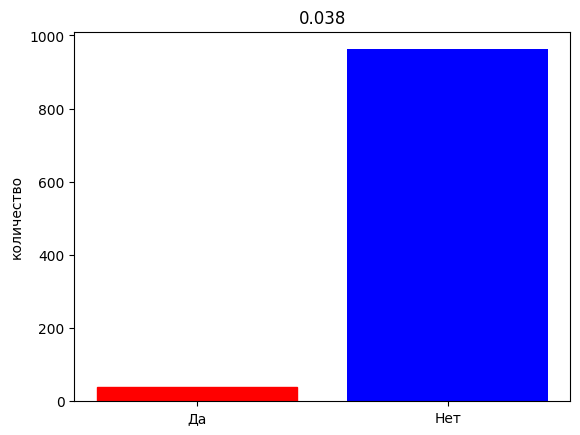

In [6]:
import scipy.stats as stats
from matplotlib import pyplot
import itertools
import numpy as np

M = 0
D = 1

def ttest(a , b):
    se = np.sqrt( a['SD']**2/a['N'] + b['SD']**2/b['N']  )
    t = (a['Mx'] - b['Mx'])/se
    dfreedom = a['N'] + b['N'] - 2
    return stats.t.sf(np.abs(t), dfreedom)*2

# n - элементов в выборке
# m - количество выборок
# a -  вероятность
def false_alarm(m, n, a):
    trys = 1000 # количество экспериментов
    hist = {'Да':0, 'Нет':0} # результаты сравнений     
    data = list(range(m)) # инициализация групп с выборками
    
    # запускаем trys экспериментов
    for i in range(trys):
        
        # наполняем m выборок, для ускорения сразу их агрегируем по SD, Mx, N
        for j in range(m):
            dt = stats.norm.rvs(loc=M, scale=D, size=n)
            data[j] = {'SD':np.std(dt, ddof = 1), 'Mx':np.mean(dt), 'N':n}
        
        #сравниваем выборки по 2 группы, перебор можно реализовать с помощью двух циклов или воспользоваться itertools
        for first, second in itertools.combinations(data, 2):
            if ttest(first, second) <= a:
                hist['Да']+=1
                break
        else:
            hist['Нет']+=1

    # рисуем гитограмму частот
    barlist = pyplot.bar(hist.keys(), hist.values(), color='b')
    barlist[0].set_color('r')
    pyplot.title(round(hist['Да'] / trys,3))
    pyplot.ylabel('количество')
    pyplot.show()
    

false_alarm(2,30,0.05)

Взяв всего 2 выборки, мы получаем всего примерно 5% случаев получем статистического значимое различие.

Однако если мы увеличим количество выборок:

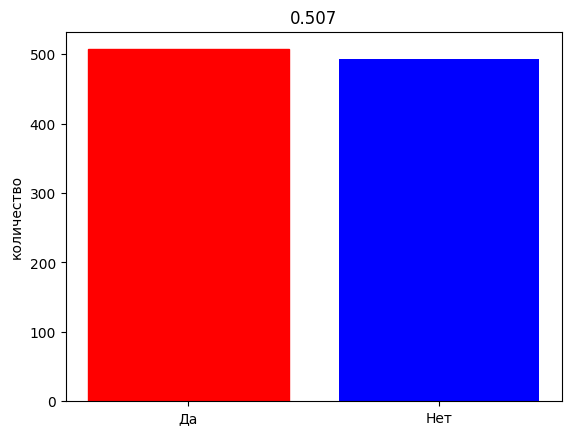

In [7]:
false_alarm(8,30,0.05)

Уже в 50% процентов случаев мы будем получать статистического значимое различие.

Увеличивая количество сравниваемых выборок, мы будем получать все больше и больше случаев статистического значимого различия. Но почему?

Если мы многократно увеличиваем количество групп, которые будут участвовать в нашем иследование и которые мы будем сравнивать друг с другом, то вероятность получить хотя бы одно значимое различие, которого не существует, очень сильно увеличивается. Приведем аналогию с монеткой, подкинув монетку 1 раз, шанс получить орла 0.5. Если мы взяли монетку и подкинули её 1000 раз вероятность получить хотя бы 1го орла начинает стремиться к 1

## Поправки на множественное сравнения (решение данной проблемы)

### Поправка Бонферрони (Идея в том, чтобы разделить уровень значимости на количество сравнений)

   -  $$ Колво-сравнений=
\frac{n!}{(n-k)!k!}$$

n — общее количество групп (выборок)

k — это количество групп, которые одновременно сравниваются в одном конкретном парном сравнении.

   - $$alpha_{new} = \frac{alpha}{Колво-сравнений}$$

Минусы Бонферрони:

- Чрезмерная консервативность (основной минус). Метод слишком строгий, значительно увеличивая риск ошибки II рода (пропустить реально существующие различия или эффекты).

- Снижение мощности теста. Из-за жесткого контроля за множественными сравнениями статистическому тесту требуется гораздо большая величина эффекта или размер выборки, чтобы обнаружить значимые различия.

- Не учитывает взаимосвязь между тестами. Поправка "втупую" делит уровень значимости на общее число сравнений, даже если эти сравнения коррелированы между собой (например, измерения одних и тех же объектов). Это приводит к излишней строгости.

- Проблема при большом числе сравнений. При проверке десятков или сотен гипотез скорректированный уровень значимости (α) становится чрезвычайно малым (например, 0.05 / 100 = 0.0005), что делает обнаружение любых различий практически невозможным.

- Негибкость. Является универсальным, но неоптимальным методом для всех ситуаций. Часто существуют более мощные альтернативы (например, поправка Холма, метод Шидака или FDR), которые лучше подходят для конкретных задач.

### Критерий Тьюки

Считается также как критерий Стьюдента только с небольшими поправками

![изображение.png](images/9.png)

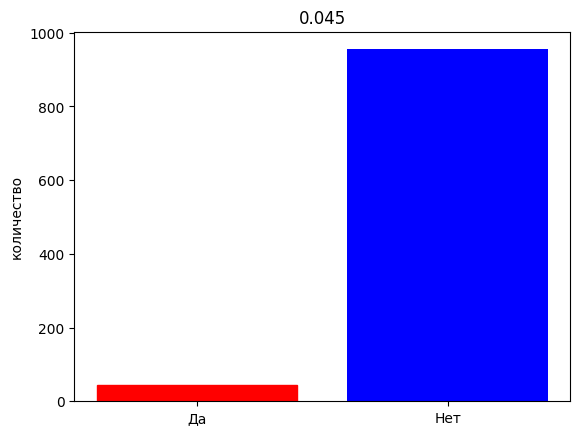

In [10]:
# Поправка Бонферрони
alpha = 0.05/28
false_alarm(8,30,alpha)

Надо будет глянуть:

https://www.youtube.com/watch?v=dcVG0NtZMwE

# Многофакторный ANOVA

Отличие от однофакторного дисперсионного анализа заключается в том, что сравнение проводится не по одному, а по нескольким (двум или более) группирующим признакам. При использовании нескольких факторов расчёты можно представить следующим образом:

Сумма квадратов между группами:

$SS_{between} = \sum_{j=1}^{p}{n_j{(\bar{x}_j - \bar{x})^2}}, \quad df = N - m$,
где $m$ — количество групп.

Сумма квадратов внутри групп:

$SS_{within} = \sum_{j=1}^{p}{\sum_{i=1}^{n_j}{(x_{ij} - \bar{x}_j)^2}}, \quad df = m - 1$,
где $m$ — количество групп.

Для анализа влияния двух факторов и их взаимодействия общая вариация ($SS_{total}$) разделяется на четыре компоненты:

- $$ SS_{total} = SSW + SSB_{A} + SSB_{B} + SSB_{B}*SSB_{A}$$
где $SSB_{A}$ и $SSB_{B}$ — вариация, объясняемая факторами A и B соответственно, а $SSB_{AB}$ — вариация, обусловленная их взаимодействием.

В случае множества признаков структура дисперсии усложняется и включает компоненты для каждого фактора, всех возможных попарных и более сложных взаимодействий.

$$
SS_{total} = SS_{within} + \sum_{i=1}^{k} SSB_{F_i} + \sum_{i<j} SSB_{F_i F_j} + \sum_{i<j<l} SSB_{F_i F_j F_l} + \ ... \ + SSB_{F_1 F_2 ... F_k}
$$

где:
- $SS_{within}$ — вариация внутри групп (ошибка),
- $SSB_{F_i}$ — вариация, объяснённая главным эффектом фактора $F_i$,
- $SSB_{F_i F_j}$ — вариация, объяснённая взаимодействием факторов $F_i$ и $F_j$,
- $SSB_{F_i F_j F_l}$ — вариация, объяснённая взаимодействием трёх факторов,
- $SSB_{F_1 F_2 ... F_k}$ — вариация, объяснённая взаимодействием всех $k$ факторов одновременно.

Примечание: На практике взаимодействия высоких порядков (например, трёх и более факторов) часто трудно интерпретировать и их вклад может быть статистически незначимым. Анализ обычно фокусируется на главных эффектах и двусторонних взаимодействиях.

**Очень редко множество признаков превышает 3-4 штук**

## Условия для проведения анализа ANOVA

- **Нормальность распределения нашей зависимой переменной в каждой из групп**
- **Гомогенность дисперсий** (Требование, чтобы дисперсия была примерно одинаковая в каждой из групп)

## **Огромное преимущество дисперсионного анализа**

При количестве наблюдений больше 50 ANOVA устойчива к нарушениям этих 2 ограничений

## Проверка гомогенности дисперсий

1. **Вариант построить Box-plot**
![изображение.png](images/10.png)
2. Тест Левена

Гипотезы теста:

$ H_{0}: D_{0}=D_{1}=D_{2}=...=D_{n}$

**$H_{1}: \text{Не все дисперсии } D_{j} \text{ равны}$**,
то есть хотя бы для одной пары групп дисперсии различаются.


## Вывод ANOVA:

ANOVA - не говорит о причино-следственной связи, он всего лишь проверяет гипотезу о взаимосвязи номинативной переменной (типа профессий например) и какой-то количественной переменной (например средней успеваемости по статистике).

ВСЕГДА спрашивайте себя:

Можно ли объяснить данные с другой стороны? Может быть, это не наша номинативная переменная (наши факторы) влияют на количественную переменную, а может быть разные градации количественной переменной обуславливают разделение на группы наших испытуемых

# А/Б тесты